# Air Quality Index (AQI) Analysis – Pune

## Project Overview
This project focuses on analyzing air quality in Pune using AQI and pollutant data.  
The goal is to clean, preprocess, and explore the dataset to identify trends, correlations, and insights about air pollution patterns.  
The analysis includes handling missing values, time-series exploration, feature scaling, encoding, and visualization.  
Additionally, synthetic datasets for classification and regression are generated to demonstrate machine learning readiness.

## Dataset Information
- Data has been gathered from **Central Pollution Control Board (CPCB)** and **data.gov.in**.  
- The two sources were merged together on the basis of **datetime** to create a unified dataset.  
- The dataset includes AQI values along with major pollutants such as PM2.5, PM10, NO2, SO2, CO, and O3.

## Group Members
- **Shourya Tiwari**  - 24070126169
- **Saafalya Sengupta**  - 24070126158
- **Shubhankar Bhan** - 24070126173


## Section 1: Setup

**Explanation:**

**Purpose:**

- This cell imports all the essential libraries needed for the project.
- pandas & numpy → data manipulation and numerical operations.
- matplotlib.pyplot & seaborn → visualization and plotting.
- pathlib.Path → to handle file paths.
- sklearn.preprocessing → tools for scaling and encoding data.

**Theory:**

Scaling (StandardScaler, MinMaxScaler, RobustScaler) ensures that numerical features are normalized, preventing large-valued features from dominating machine learning models. LabelEncoder converts categorical data into numeric form.

**Settings:**

- Display all columns (display.max_columns = None).
- Set console output width for readability.
- Default figure size is defined for plots.

In [ ]:
# === Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (10, 5)

## Section 2: Data Acquisition / Loading

**Explanation:**

**Purpose:** Reads the dataset (pune_aqi_pollutants.xlsx) into a pandas DataFrame.

**Theory:**
- An Excel file may contain multiple sheets. pd.ExcelFile() is used to first check sheet names.
- The default sheet is loaded using .parse().
- Inspecting the shape (rows × columns) and .head() gives a quick overview.

**Result:**
- We now have the dataset in memory (df).
- We can see the first 5 rows of the dataset.
- This helps ensure the file path and sheet loading are correct.

In [ ]:
# === Data Acquisition / Loading
data_path = Path("/content/pune_aqi_pollutants.xlsx")
xls = pd.ExcelFile(data_path)
print("Sheets:", xls.sheet_names)

# Load first sheet by default
df = xls.parse(xls.sheet_names[0])
print("Shape:", df.shape)
df.head()

Sheets: ['AQI and Pollutants']
Shape: (28424, 11)


,DateTime,AQI,PM10,PM2.5,PM 1,O3,CO,NO,NO2,NOx,CO2
0,2020-02-01 00:00:00,NaN,90.18,60.95,29.05,7.0,NaN,2.34,6.02,8.36,NaN
1,2020-02-01 01:00:00,NaN,92.45,63.70,31.28,8.0,NaN,2.39,5.97,8.37,NaN
2,2020-02-01 02:00:00,NaN,80.60,56.40,28.53,7.0,NaN,2.47,5.94,8.41,NaN
3,2020-02-01 03:00:00,NaN,82.83,57.20,28.75,7.0,NaN,2.63,6.04,8.67,NaN
4,2020-02-01 04:00:00,NaN,79.10,54.33,27.53,7.0,NaN,2.28,6.01,8.29,NaN


## Section 3: Column Name Cleanup

**Explanation:**

**Purpose:** Cleans up column names for easier handling in Python.

**Theory:**
- Column names in raw Excel often contain line breaks, spaces, or special characters (like /).
- Replacing them with underscores (_) makes them valid identifiers and easier to use in code.

**Result:**

- The dataset now has clean, standardized column names.
- This prevents issues when referencing columns in further analysis.

In [ ]:
# === Column name cleanup
df.columns = [str(c).strip().replace('\n',' ').replace('\r',' ').replace('  ',' ') for c in df.columns]
df.columns = [c.replace('/', '_').replace(' ', '_') for c in df.columns]
df.columns


Index(['DateTime', 'AQI', 'PM10', 'PM2.5', 'PM_1', 'O3', 'CO', 'NO', 'NO2', 'NOx', 'CO2'], dtype='object')

## Section 4: Structure & Missingness

**Overview:**  
This step explores the structure of the dataset and checks for missing values.  
- `df.info()` gives data types, non-null counts, and memory usage.  
- `df.describe(include='all')` provides descriptive statistics for both numeric and categorical columns.

**Explanation of Results:**  
- From `df.info()`, we can identify which columns have missing values and the overall structure.  
- The descriptive statistics help understand distributions, common values, and potential data quality issues.  
This step is important before preprocessing or model building.


In [ ]:
# === Structure & Missingness
print(df.info())

# Descriptive statistics (numeric + categorical)
display(df.describe(include='all').transpose())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28424 entries, 0 to 28423
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  28424 non-null  datetime64[ns]
 1   AQI       19131 non-null  float64       
 2   PM10      21027 non-null  float64       
 3   PM2.5     21026 non-null  float64       
 4   PM_1      21027 non-null  float64       
 5   O3        20988 non-null  float64       
 6   CO        20860 non-null  float64       
 7   NO        20849 non-null  float64       
 8   NO2       20849 non-null  float64       
 9   NOx       20848 non-null  float64       
 10  CO2       20858 non-null  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 2.4 MB
None


,count,mean,min,25%,50%,75%,max,std
DateTime,28424,2021-11-11 15:39:29.054320640,2020-02-01 00:00:00,2020-11-23 01:45:00,2021-09-15 03:30:00,2023-01-21 10:15:00,2023-12-31 07:00:00,NaN
AQI,19131.0,168.284198,13.0,112.0,160.0,225.0,500.0,73.924113
PM10,21027.0,66.244568,2.15,24.46,54.98,98.84,1614.55,49.407991
PM2.5,21026.0,45.00268,1.5,17.73,38.08,64.75,1193.85,33.098818
PM_1,21027.0,26.102154,0.1,9.5,22.23,38.22,668.53,19.908092
O3,20988.0,15.070457,1.0,8.0,12.0,18.0,98.0,10.623075
CO,20860.0,2.515289,0.01,0.71,0.9,1.05,32.82,4.794939
NO,20849.0,8.014404,0.62,3.67,5.71,9.11,58.86,7.327593
NO2,20849.0,8.238812,0.5,4.95,7.77,10.61,46.9,5.263086
NOx,20848.0,17.13474,1.49,9.44,13.77,19.83,135.0,13.187579


## Section 5: Missing Values Summary

**Overview:**  
This step calculates the number and percentage of missing values for each column.  
- `df.isna().sum()` → counts missing values.  
- Dividing by dataset length gives missing value percentage.  
- Sorted by highest missing count for easier inspection.

**Explanation of Results:**  
The output highlights which variables have the most missing data.  
This helps decide whether to impute, drop, or otherwise handle missing values in preprocessing.

In [ ]:
# Missing values summary
missing_summary = df.isna().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_pct
AQI,9293,32.69
NOx,7576,26.65
NO,7575,26.65
NO2,7575,26.65
CO2,7566,26.62
CO,7564,26.61
O3,7436,26.16
PM2.5,7398,26.03
PM10,7397,26.02
PM_1,7397,26.02


## Section 6: Datetime Parsing

**Overview:**  
This step attempts to detect and parse any columns related to dates or times.  
- Identifies columns containing "date" or "time" in their names.  
- Converts them to proper datetime format using `pd.to_datetime()`.  
- If separate date and time columns exist, it combines them into a single datetime.  
- Finally, sets the parsed datetime as the DataFrame index (if available).

**Explanation of Results:**  
- Successfully parsed columns will now be in datetime format.  
- If a valid datetime column is found, the dataset is sorted chronologically and indexed by time.  
- If no datetime is available, the dataset continues with its original index.  
This step is essential for any time series analysis or trend exploration later in the project.

In [ ]:
# === Datetime Parsing
# Try to parse potential datetime columns automatically.

datetime_candidates = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
print("Potential datetime columns:", datetime_candidates)

for col in datetime_candidates:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"Parsed datetime: {col}")
    except Exception as e:
        print(f"Could not parse {col}: {e}")

# If separate date & time columns exist, try to combine them
possible_date_cols = [c for c in df.columns if 'date' in c.lower()]
possible_time_cols = [c for c in df.columns if 'time' in c.lower() and c not in possible_date_cols]

if possible_date_cols and possible_time_cols:
    date_col = possible_date_cols[0]
    time_col = possible_time_cols[0]
    try:
        df['__combined_datetime'] = pd.to_datetime(
            df[date_col].astype(str) + ' ' + df[time_col].astype(str),
            errors='coerce'
        )
        print("Created combined datetime column: __combined_datetime")
    except Exception as e:
        print("Combine datetime failed:", e)

# Choose a working datetime index if available
dt_col = None
for c in ['__combined_datetime'] + datetime_candidates:
    if c in df.columns and pd.api.types.is_datetime64_any_dtype(df[c]):
        dt_col = c
        break

if dt_col is not None:
    df = df.sort_values(dt_col).reset_index(drop=True)
    df = df.set_index(dt_col)
    print("Using datetime index:", dt_col)
else:
    print("No usable datetime column found — continuing without datetime index.")


Potential datetime columns: ['DateTime']
Parsed datetime: DateTime
Using datetime index: DateTime


## Section 7: Removing Duplicates

**Overview:**  
This step ensures there are no duplicate rows in the dataset.  
- If a datetime index exists → remove duplicate timestamps, keeping the first occurrence.  
- Otherwise → remove fully duplicated rows across all columns.

**Explanation of Results:**  
- The output message shows how many duplicate rows were removed.  
- This step prevents bias or errors in analysis caused by repeated records.

In [ ]:
# === Remove duplicates
if isinstance(df.index, pd.DatetimeIndex):
    before = len(df)
    df = df[~df.index.duplicated(keep='first')]
    after = len(df)
    print(f"Removed {before - after} duplicate rows based on datetime index.")
else:
    before = len(df)
    df = df.drop_duplicates()
    after = len(df)
    print(f"Removed {before - after} duplicate rows based on all columns.")


Removed 0 duplicate rows based on datetime index.


## Section 8: Imputation Plan

**Overview:**  
This step handles missing values by applying different strategies based on column type:  
- **Numeric columns:** filled with the column median.  
- **Categorical columns:** filled with the most frequent value (mode). If no mode exists, filled with `"Unknown"`.  
- **Datetime index present:** numeric columns are forward-filled to maintain time series continuity.

**Explanation of Results:**  
- The `impute_report` dictionary shows how each column was imputed.  
- This ensures there are no missing values left in the dataset, making it ready for further analysis.  
- Using median and mode preserves the data distribution while avoiding bias from extreme values.

In [ ]:
# === Imputation Plan
# Numeric -> median; Categorical -> mode
# If datetime index exists: also forward-fill for numeric time series

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in df.columns if c not in numeric_cols]

impute_report = {}

# Forward fill for time series data
if isinstance(df.index, pd.DatetimeIndex):
    df[numeric_cols] = df[numeric_cols].ffill()

# Numeric columns: fill with median
for c in numeric_cols:
    med = df[c].median()
    df[c] = df[c].fillna(med)
    impute_report[c] = f"numeric-median({med})"

# Categorical columns: fill with mode (most frequent value)
for c in categorical_cols:
    mode_val = df[c].mode(dropna=True)
    if len(mode_val):
        df[c] = df[c].fillna(mode_val[0])
        impute_report[c] = f"categorical-mode({mode_val[0]})"
    else:
        df[c] = df[c].fillna('Unknown')
        impute_report[c] = "categorical-filled-Unknown"

impute_report

{'AQI': 'numeric-median(158.0)',
 'PM10': 'numeric-median(31.73)',
 'PM2.5': 'numeric-median(22.18)',
 'PM_1': 'numeric-median(12.68)',
 'O3': 'numeric-median(9.0)',
 'CO': 'numeric-median(0.98)',
 'NO': 'numeric-median(7.65)',
 'NO2': 'numeric-median(5.89)',
 'NOx': 'numeric-median(15.0)',
 'CO2': 'numeric-median(416.98)'}

## Section 9: Dataset Info & Summary

**Overview:**  
This step provides a final check of the dataset after cleaning and imputation.  
- `df.info()` → shows column names, data types, and non-null counts.  
- `df.describe(include='all')` → summary statistics for both numeric and categorical variables.

**Explanation of Results:**  
- Confirms that missing values have been handled.  
- Numeric columns show statistics like mean, median, min, max, and quartiles.  
- Categorical columns show counts, unique values, and most frequent categories.  
This step verifies the dataset is now consistent and ready for deeper analysis or modeling.

In [ ]:
# --- Dataset Info & Summary ---

print("\n--- Dataset Info ---")
df.info()

print("\n--- Dataset Summary ---")
print(df.describe(include='all').transpose())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28424 entries, 2020-02-01 00:00:00 to 2023-12-31 07:00:00
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AQI     28424 non-null  float64
 1   PM10    28424 non-null  float64
 2   PM2.5   28424 non-null  float64
 3   PM_1    28424 non-null  float64
 4   O3      28424 non-null  float64
 5   CO      28424 non-null  float64
 6   NO      28424 non-null  float64
 7   NO2     28424 non-null  float64
 8   NOx     28424 non-null  float64
 9   CO2     28424 non-null  float64
dtypes: float64(10)
memory usage: 3.4 MB

--- Dataset Summary ---
         count        mean        std     min     25%     50%       75%      max
AQI    28424.0  164.755699  62.173588   13.00  127.00  158.00  207.0000   500.00
PM10   28424.0   52.690064  48.345902    2.15   13.70   31.73   82.7000  1614.55
PM2.5  28424.0   35.323593  32.878323    1.50    7.50   22.18   55.3625  1193.85


## Section 10: EDA – Correlations & Distributions

**Overview:**  
This step explores relationships between variables and examines their distributions.  
- **Correlation Heatmap:**  
  - Displays correlations among numeric features using a heatmap.  
  - Helps identify strongly related variables, multicollinearity, or redundant features.  
- **Distribution Plots:**  
  - Histograms with KDE (Kernel Density Estimate) are plotted for AQI and major pollutants (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`).  
  - Shows how each variable is distributed across the dataset.

**Explanation of Results:**  
- The correlation heatmap reveals which pollutants are strongly associated with each other and with AQI.  
- Distribution plots highlight data skewness, spread, and outliers.  
This step provides insights into variable behavior and relationships, guiding later analysis or modeling.

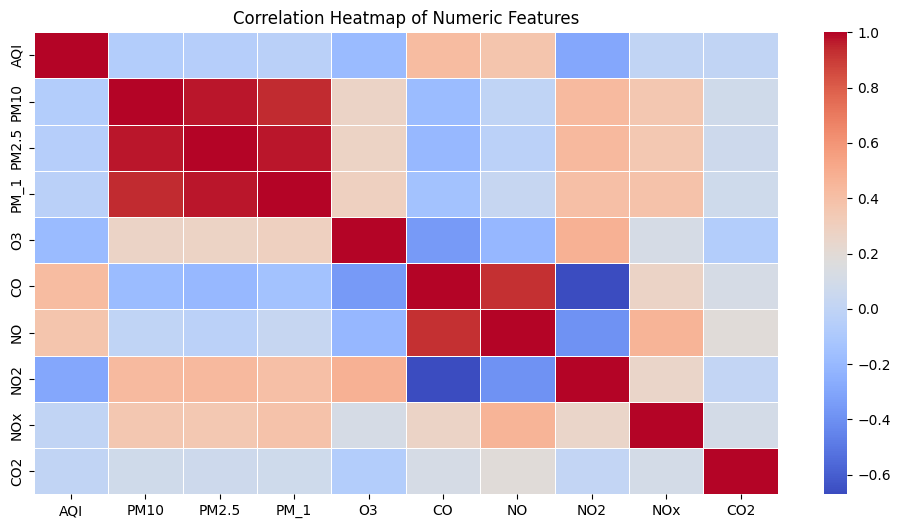

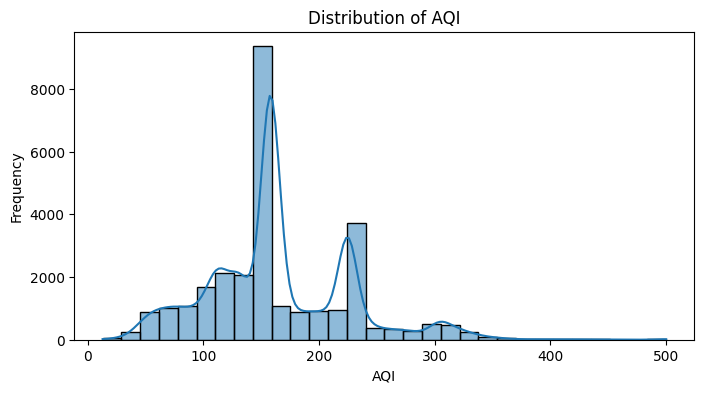

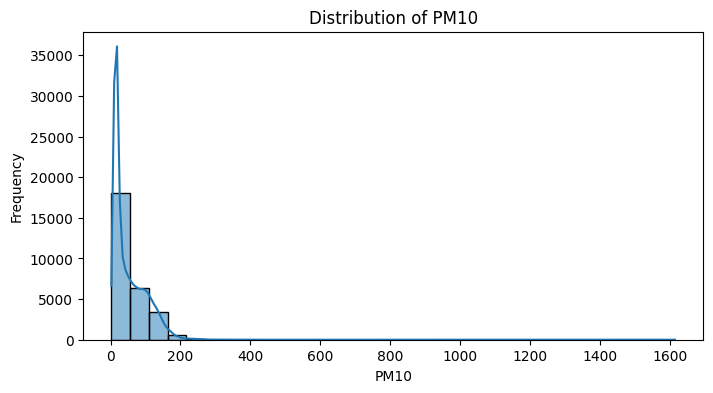

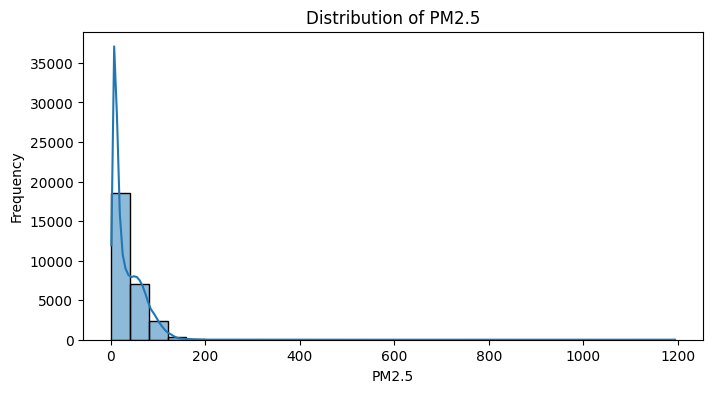

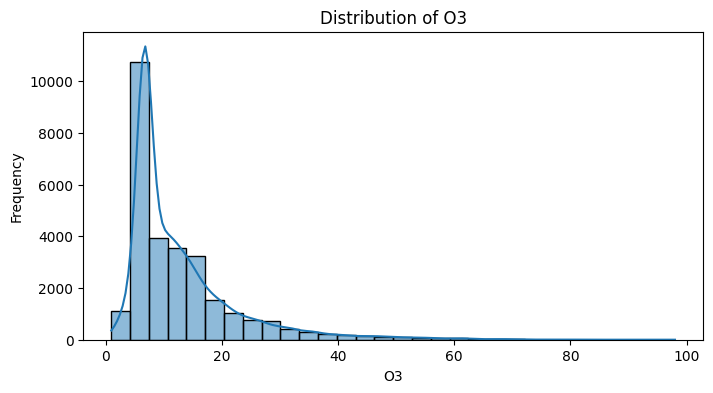

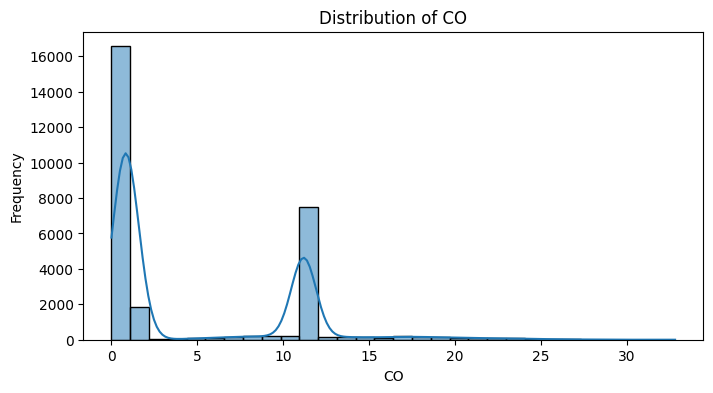

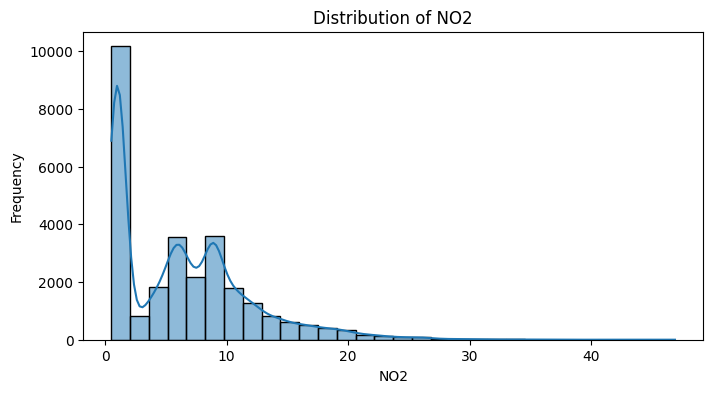

In [ ]:
# === Block 9: EDA - Correlations & Distributions ===

# Correlation matrix for numeric columns
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Distribution plots of AQI and main pollutants
main_cols = [c for c in df.columns if c.lower() in ["aqi", "pm2.5", "pm10", "no2", "so2", "co", "o3"]]

for col in main_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


## Section 11: Time-Series Visualization

**Overview:**  
This step visualizes how AQI and pollutant levels change over time.  
- **AQI Trend Plot:** Line chart showing the variation of AQI across the timeline.  
- **Pollutant Trends:** Plots of key pollutants (`PM2.5`, `PM10`, `NO2`, `SO2`) to observe seasonal or temporal patterns.

**Explanation of Results:**  
- The AQI trend reveals periods of high or low air quality, useful for identifying seasonal pollution peaks.  
- Pollutant trend lines show how different pollutants fluctuate over time, and whether certain pollutants follow similar patterns.  
This step is crucial for understanding the temporal behavior of air quality in Pune.

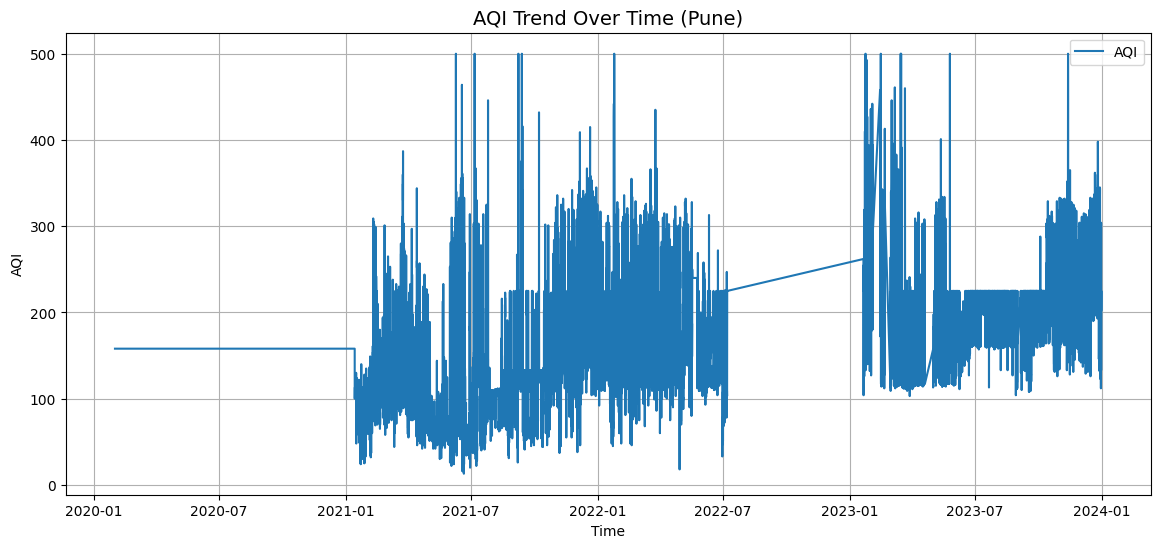

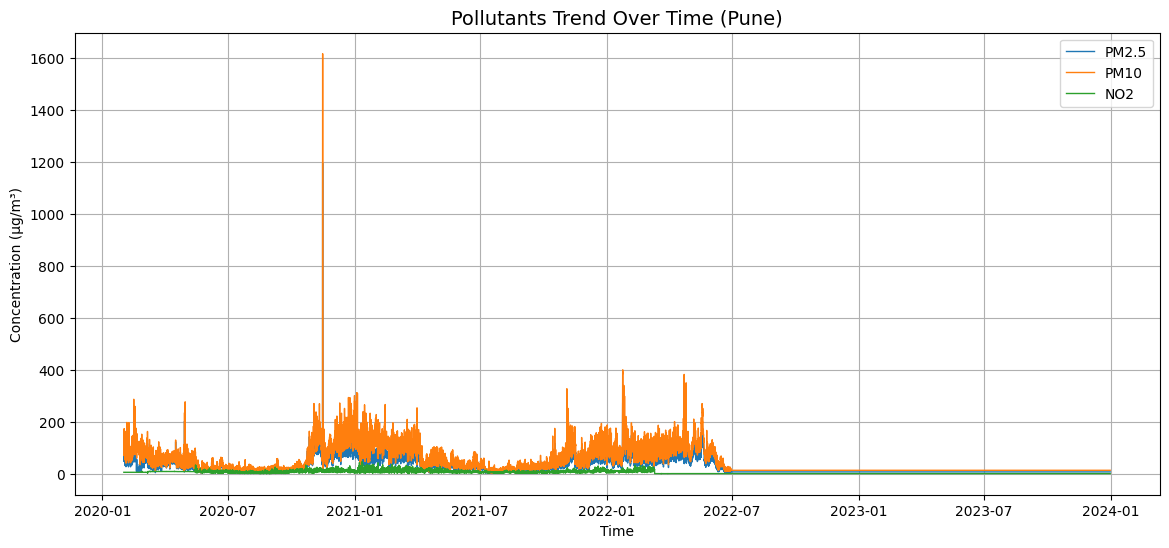

In [ ]:
# --- Block 11: Time-Series Visualization ---

# Plot AQI trend over time
plt.figure(figsize=(14,6))
plt.plot(df.index, df['AQI'], label='AQI', linewidth=1.5)
plt.title("AQI Trend Over Time (Pune)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()

# Plot pollutants trend (just a few major ones to start)
plt.figure(figsize=(14,6))
for col in ['PM2.5', 'PM10', 'NO2', 'SO2']:
    if col in df.columns:
        plt.plot(df.index, df[col], label=col, linewidth=1)

plt.title("Pollutants Trend Over Time (Pune)", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Concentration (µg/m³)")
plt.legend()
plt.grid(True)
plt.show()

## Section 12: Resampling for Smoother AQI Trends

**Overview:**  
This step resamples the AQI time series to view aggregated trends:  
- **Daily average:** smooths out short-term fluctuations by averaging values per day.  
- **Monthly average:** highlights long-term seasonal or monthly trends.

**Explanation of Results:**  
- The daily plot helps detect short-term patterns like weekday vs. weekend differences or sudden pollution spikes.  
- The monthly plot makes it easier to see seasonal variations and long-term changes in air quality.  
Resampling is a common time-series technique to reduce noise and highlight meaningful trends.

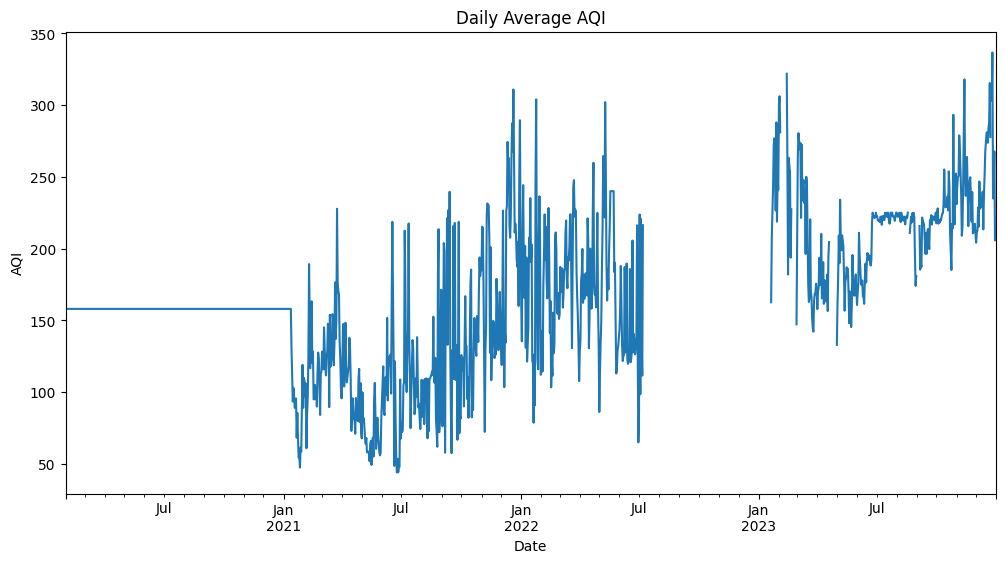

/tmp/ipython-input-285402327.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['AQI'].resample('M').mean().plot(figsize=(12,6), title='Monthly Average AQI')


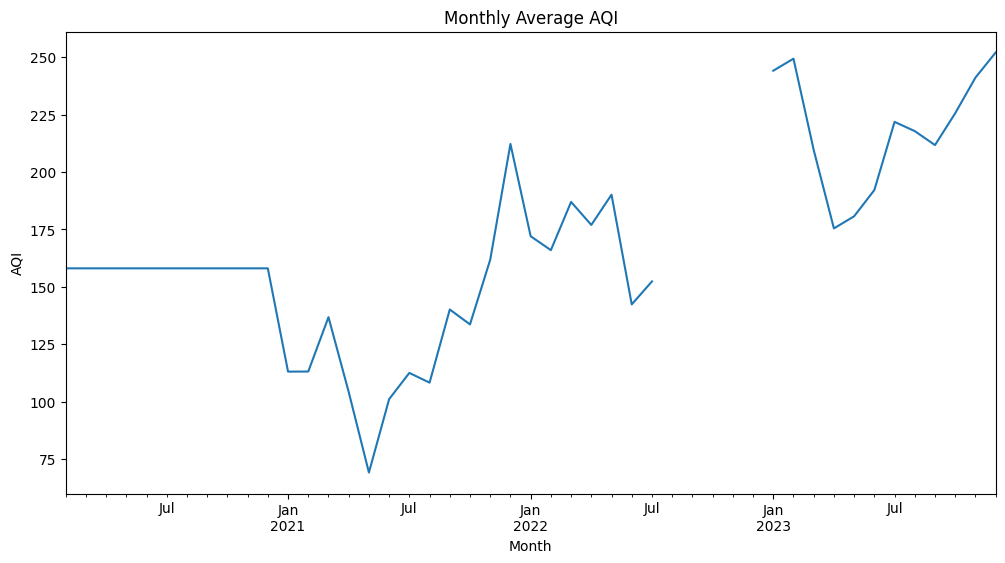

In [ ]:
# --- Step 12: Resampling for smoother AQI trends ---

# Daily average
df['AQI'].resample('D').mean().plot(figsize=(12,6), title='Daily Average AQI')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

# Monthly average
df['AQI'].resample('M').mean().plot(figsize=(12,6), title='Monthly Average AQI')
plt.xlabel('Month')
plt.ylabel('AQI')
plt.show()


## Section 13: Scaling Numeric Columns

**Overview:**  
This step applies different feature scaling methods to the numeric columns:  
- **StandardScaler:** standardizes data (mean = 0, std = 1).  
- **MinMaxScaler:** rescales values to a fixed range (default 0–1).  
- **RobustScaler:** scales using median and IQR, making it less sensitive to outliers.

**Explanation of Results:**  
- Each scaler transforms the numeric columns and stores the results in `scaled_dfs`.  
- Viewing the `.head()` confirms that the scaling was applied correctly.  
- Scaling ensures that all numeric features are comparable in magnitude, which is critical for machine learning models.  

In [ ]:
# --- Scaling Numeric Columns ---
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

scaled_dfs = {}

for name, scaler in scalers.items():
    scaled_array = scaler.fit_transform(df[numeric_cols])
    scaled_dfs[name] = pd.DataFrame(scaled_array, columns=numeric_cols, index=df.index)
    print(f"{name} applied successfully. Sample:")
    display(scaled_dfs[name].head())


StandardScaler applied successfully. Sample:


,AQI,PM10,PM2.5,PM_1,O3,CO,NO,NO2,NOx,CO2
DateTime,,,,,,,,,,
2020-02-01 00:00:00,-0.108661,0.775466,0.779445,0.433063,-0.600538,-0.671313,-1.068172,-0.061461,-0.718300,0.108305
2020-02-01 01:00:00,-0.108661,0.822420,0.863089,0.547438,-0.498913,-0.671313,-1.061641,-0.070534,-0.717420,0.108305
2020-02-01 02:00:00,-0.108661,0.577307,0.641054,0.406392,-0.600538,-0.671313,-1.051192,-0.075978,-0.713897,0.108305
2020-02-01 03:00:00,-0.108661,0.623434,0.665386,0.417676,-0.600538,-0.671313,-1.030294,-0.057832,-0.691002,0.108305
2020-02-01 04:00:00,-0.108661,0.546280,0.578093,0.355103,-0.600538,-0.671313,-1.076009,-0.063276,-0.724464,0.108305


MinMaxScaler applied successfully. Sample:


,AQI,PM10,PM2.5,PM_1,O3,CO,NO,NO2,NOx,CO2
DateTime,,,,,,,,,,
2020-02-01 00:00:00,0.297741,0.054596,0.049860,0.043310,0.061856,0.029564,0.029533,0.118966,0.051457,0.488378
2020-02-01 01:00:00,0.297741,0.056003,0.052166,0.046647,0.072165,0.029564,0.030391,0.117888,0.051532,0.488378
2020-02-01 02:00:00,0.297741,0.048654,0.046044,0.042533,0.061856,0.029564,0.031765,0.117241,0.051831,0.488378
2020-02-01 03:00:00,0.297741,0.050037,0.046714,0.042862,0.061856,0.029564,0.034512,0.119397,0.053779,0.488378
2020-02-01 04:00:00,0.297741,0.047724,0.044307,0.041036,0.061856,0.029564,0.028503,0.118750,0.050933,0.488378


RobustScaler applied successfully. Sample:


,AQI,PM10,PM2.5,PM_1,O3,CO,NO,NO2,NOx,CO2
DateTime,,,,,,,,,,
2020-02-01 00:00:00,0.0,0.847101,0.810029,0.583601,-0.215285,0.0,-0.393042,0.015951,-1.127334,0.0
2020-02-01 01:00:00,0.0,0.880000,0.867485,0.663102,-0.107643,0.0,-0.389341,0.009816,-1.125637,0.0
2020-02-01 02:00:00,0.0,0.708261,0.714965,0.565062,-0.215285,0.0,-0.383420,0.006135,-1.118846,0.0
2020-02-01 03:00:00,0.0,0.740580,0.731679,0.572906,-0.215285,0.0,-0.371577,0.018405,-1.074703,0.0
2020-02-01 04:00:00,0.0,0.686522,0.671716,0.529412,-0.215285,0.0,-0.397483,0.014724,-1.139219,0.0


## Section 14: Encoding Categorical Variables

**Overview:**  
This step converts categorical features into numerical form so they can be used in machine learning models:  
- **Label Encoding:** assigns each category a unique integer value.  
- **One-Hot Encoding:** creates binary dummy variables for each category (dropping the first to avoid redundancy).

**Explanation of Results:**  
- The label-encoded DataFrame shows categorical columns converted into integers.  
- The one-hot encoded DataFrame expands categorical variables into multiple binary columns, with the shape printed to confirm the transformation.  
Encoding is essential for algorithms that require purely numerical input.

In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_label_encoded = df.copy()
for col in categorical_cols:
    df_label_encoded[col] = le.fit_transform(df[col])
display(df_label_encoded[categorical_cols].head())

# One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("One-hot encoded dataset shape:", df_onehot.shape)


""
DateTime
2020-02-01 00:00:00
2020-02-01 01:00:00
2020-02-01 02:00:00
2020-02-01 03:00:00
2020-02-01 04:00:00


One-hot encoded dataset shape: (28424, 10)


## Section 15: Advanced Visualizations

**Overview:**  
This step uses different plots to explore AQI and pollutant relationships:  
- **Scatter Plot (AQI vs PM2.5):** shows how PM2.5 levels influence AQI.  
- **KDE Plot (AQI):** estimates the probability density of AQI values.  
- **Violin Plot (AQI by Month):** visualizes seasonal variation in AQI, if datetime is available.  
- **Pair Plot (Main Pollutants):** shows pairwise scatterplots and distributions for selected features.  
- **Joint Plot (AQI vs PM10):** highlights the relationship between AQI and PM10 with both scatter and density.

**Explanation of Results:**  
- Scatter and joint plots reveal the strength of association between pollutants and AQI.  
- KDE and violin plots show how AQI values are distributed overall and across months.  
- The pair plot provides a compact view of correlations and spreads across multiple pollutants.  
These visualizations give deeper insight into pollutant behavior and their effect on AQI.

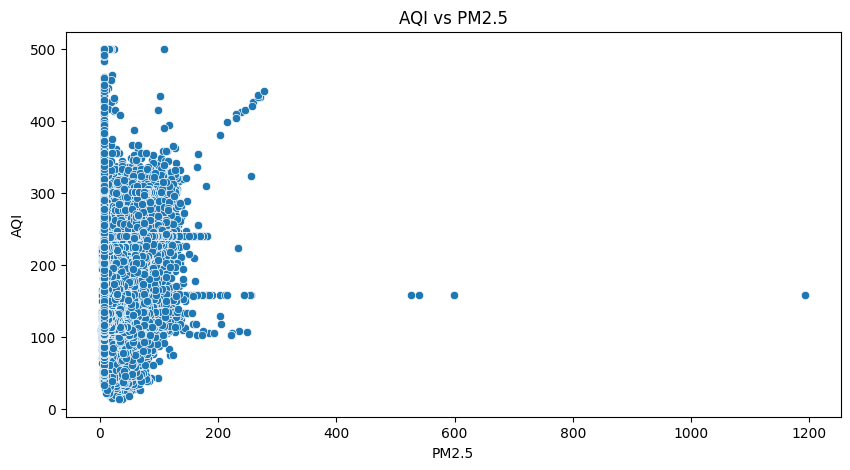

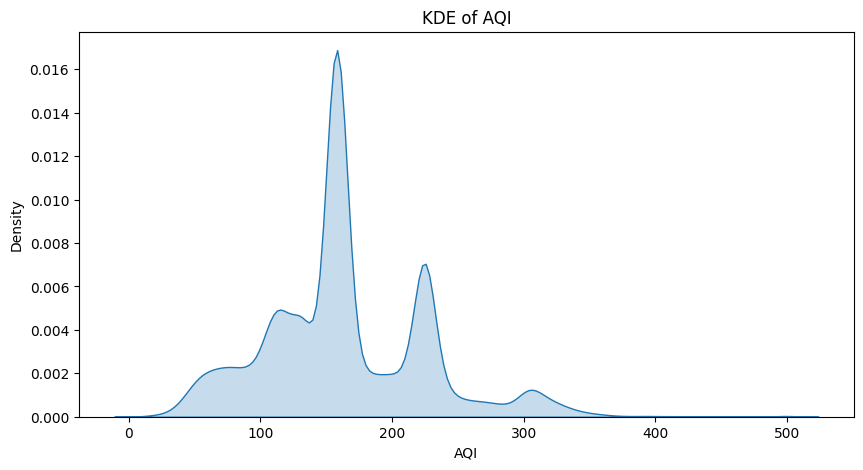

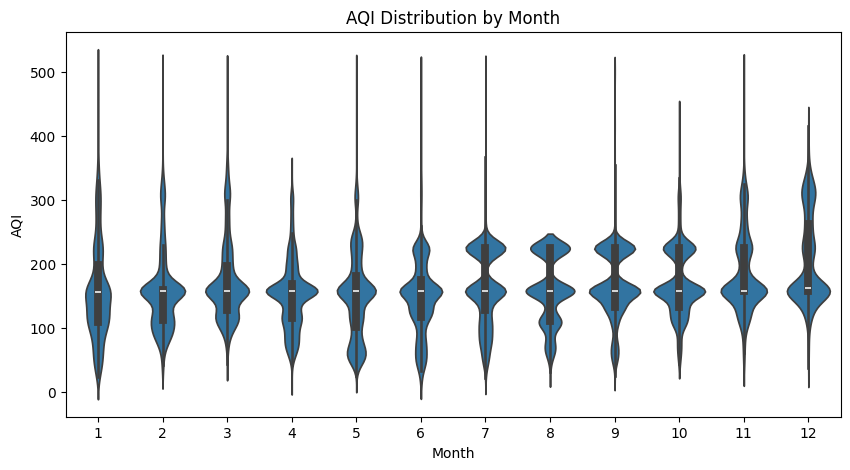

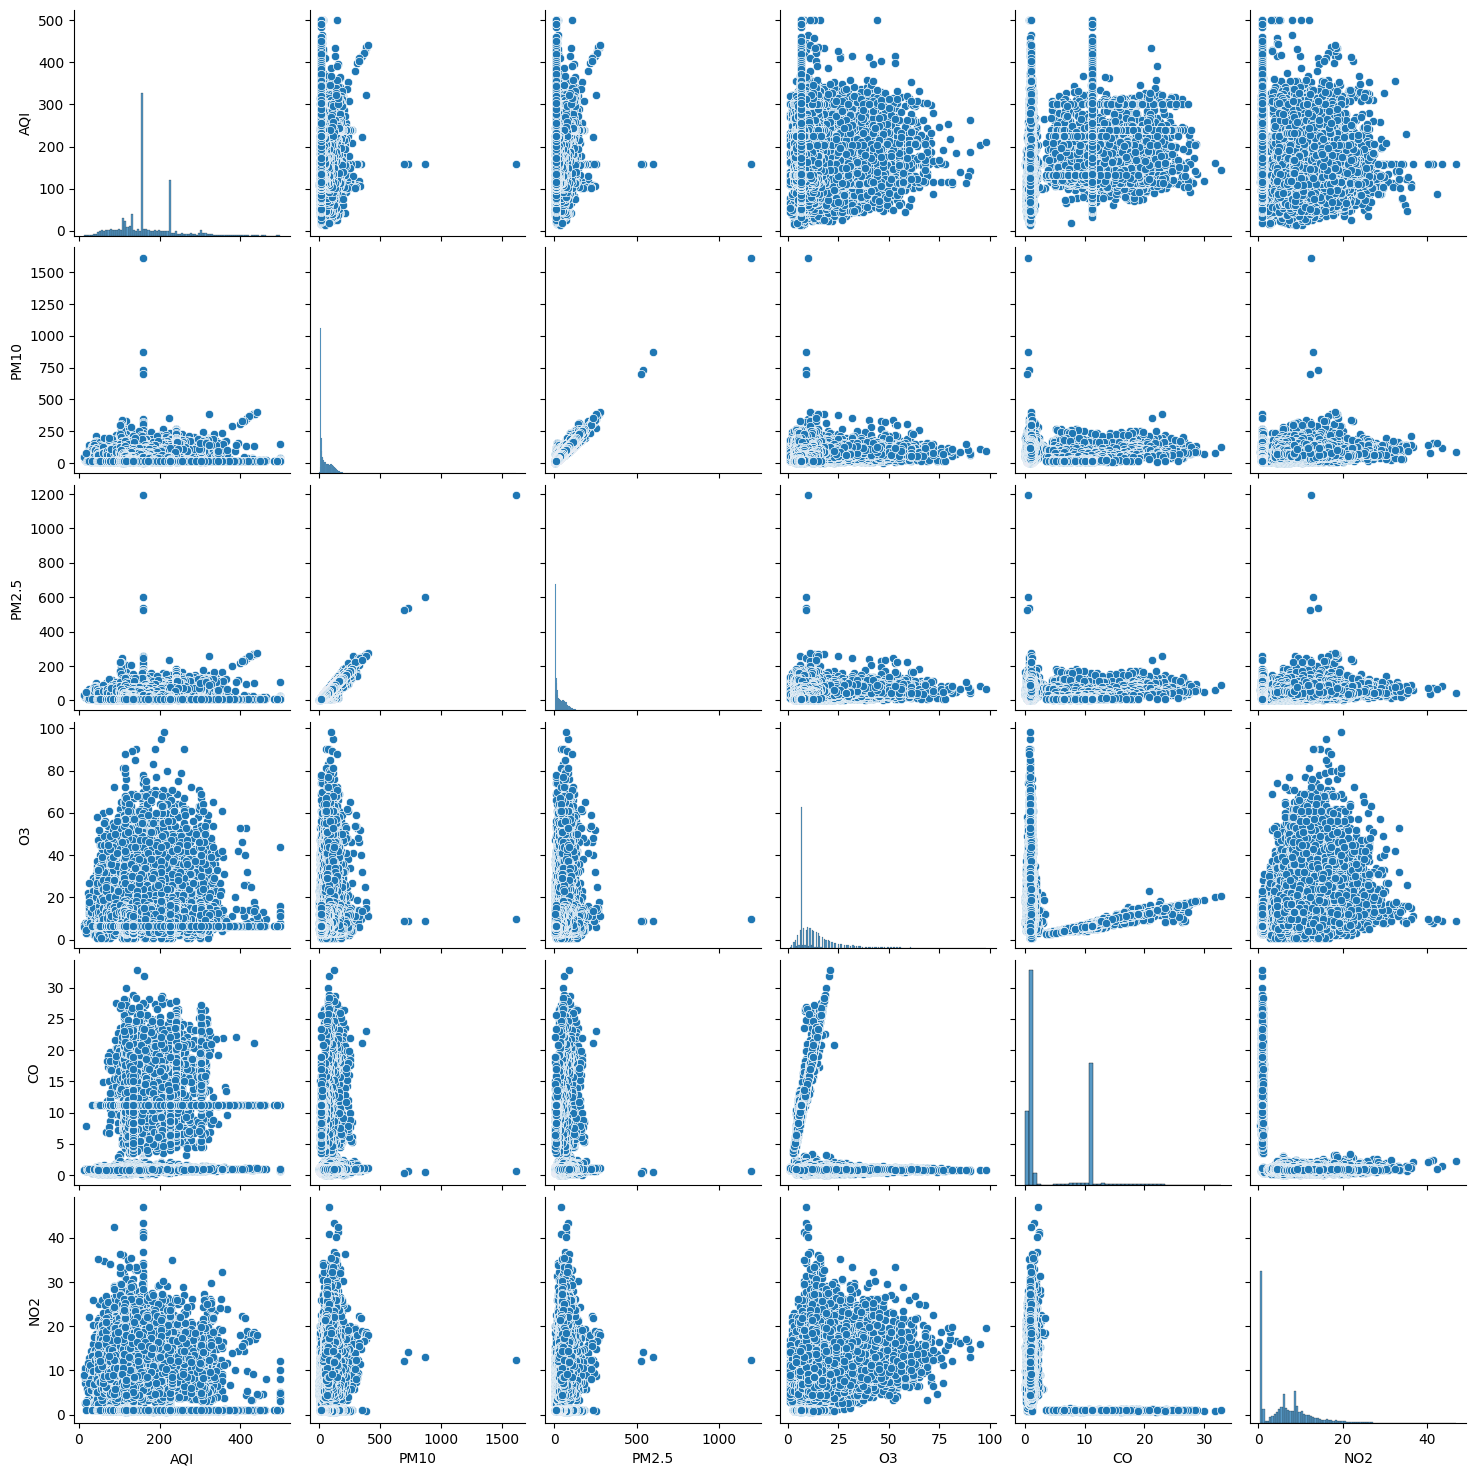

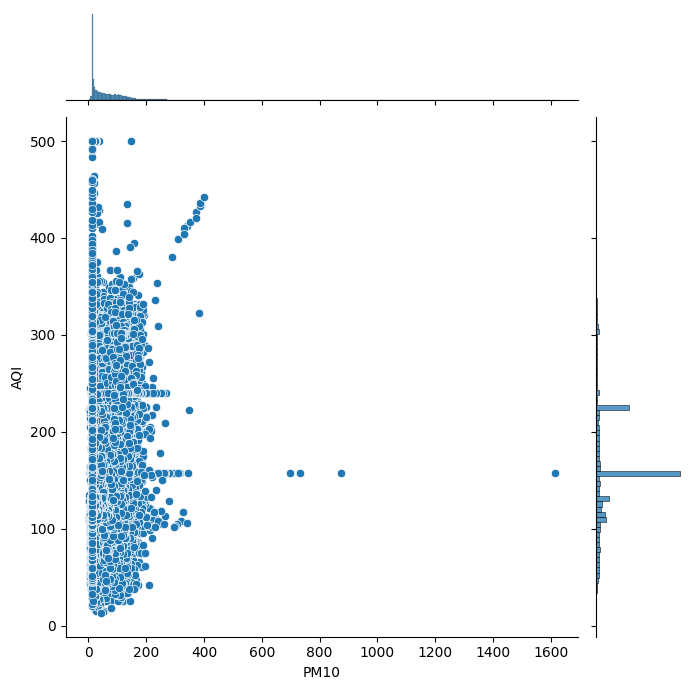

In [ ]:
# Scatter Plot: AQI vs PM2.5
if 'AQI' in df.columns and 'PM2.5' in df.columns:
    sns.scatterplot(data=df, x='PM2.5', y='AQI')
    plt.title("AQI vs PM2.5")
    plt.show()

# KDE Plot: AQI
sns.kdeplot(df['AQI'], fill=True)
plt.title("KDE of AQI")
plt.show()

# Violin Plot: AQI distribution by month (if datetime index exists)
if isinstance(df.index, pd.DatetimeIndex):
    df['Month'] = df.index.month
    sns.violinplot(x='Month', y='AQI', data=df)
    plt.title("AQI Distribution by Month")
    plt.show()

# Pair Plot: select main numeric columns
sns.pairplot(df[main_cols].dropna())
plt.show()

# Joint Plot: AQI vs PM10
if 'AQI' in df.columns and 'PM10' in df.columns:
    sns.jointplot(data=df, x='PM10', y='AQI', kind='scatter', height=7)
    plt.show()


# Conclusion & Next Steps:

## Summary
In this project, we successfully:  
- Collected and merged AQI and pollutant data from **CPCB** and **data.gov.in**.  
- Cleaned and standardized the dataset (column names, missing values, duplicates).  
- Parsed datetime information and structured the dataset for time-series analysis.  
- Performed exploratory data analysis (EDA) using correlations, distributions, and trend visualizations.  
- Applied preprocessing techniques including scaling and encoding to prepare the dataset for machine learning.   

## Key Insights
- Strong correlations were observed between AQI and pollutants such as PM2.5 and PM10.  
- Seasonal variations in AQI trends suggest recurring pollution peaks.  
- Data preprocessing ensures that the dataset is now machine learning–ready.  

## Next Steps
As part of the continuation of this project, we are working on developing **machine learning models** to:  
- Predict AQI based on pollutant concentrations.  
- Explore classification models for categorizing air quality levels (e.g., Good, Moderate, Poor).  
- Investigate regression models for accurate AQI forecasting.  

This modeling phase will enhance our ability to **predict and analyze air quality in Pune**, supporting better policy-making and awareness.

